# Quantization and Barycenter Computation for GMMs

As our target data, we load MNIST images and fit Gaussian mixtures to the pixel intensities.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


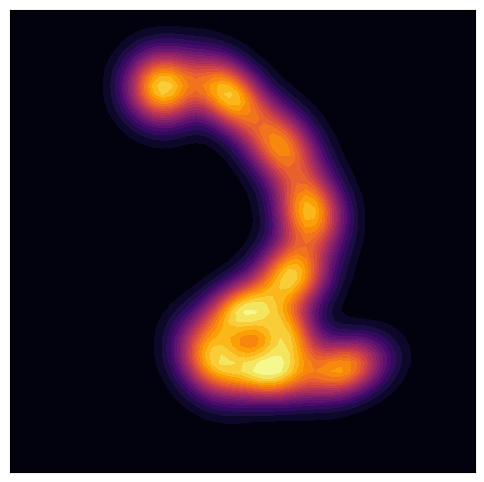

In [287]:
import ImageGMM as ImgGMM
import GMM_utils as GMM
import sliced_mw as smw 

idx = 20
idx2 = 30
gmm1, label1 = ImgGMM.get_mnist_gmm(idx, num_components=10, train=False, target_label=2, var=1., nsample=5000, type_cov="spherical",
                                   n_init=1)
ImgGMM.plot_gmm_contours(gmm1, label=label1)

## DSMW Barycenter

Next, we load images/GMMs for each class and estimate free-support barycenters based on our sliced DSMW (or SMSW in the code) metric.

In [156]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
np.random.seed(42)
torch.manual_seed(42)

restart_num = 10
for tl in range( 10):
    #gmm1 = GMM.DiagonalGMM(torch.randn(50, 2), optimize="diag")
    torch.manual_seed(tl)
    np.random.seed(tl)
    print(f"Perform {restart_num} optimization schemes for class {tl}...")  
    target_gmms = [ImgGMM.get_mnist_gmm(idx, num_components=10, train=False, requires_grad=False, target_label=tl)[0] for idx in range(5)]
    final_loss = 1e8
    
    # iterative over multiple initializations
    for seed in range(restart_num):
        torch.manual_seed(seed)
        np.random.seed(seed)
        gmm1 = GMM.RandomGaussianMixtureModel(100, 2, optimize=True, normal_means=True)
        with torch.no_grad():
            gmm1.means *= 5.
            gmm1.means += 14.
        l_ls = []
        gmm1 = gmm1.cuda()
        gmm2 = gmm2.cuda()
        min_loss = 1e8
        opt = torch.optim.Adam(gmm1.parameters(), lr=.03)
        for i in tqdm(range(201)):
            opt.zero_grad()
            gmm1.set_conditions()
            diag = torch.eye(gmm1.covariances.shape[-1]).unsqueeze(0).cuda()
            s = gmm1.covariances.shape[0]
            gmm1.covariances += .3 * diag.repeat(s, 1, 1)
            multi_smsw = 0.
            for gmm2 in target_gmms:
                multi_smsw += smw.calc_parallel_SMSW(gmm1, gmm2, pnum=100)
            multi_smsw.backward()
            l_ls.append(multi_smsw.item())
            opt.step()

        # Keep the one with the lowest sliced distance
        if multi_smsw < final_loss:
            gmm_final = gmm1
            final_loss = multi_smsw
    print(f"Done for {tl}\n")               
    ImgGMM.plot_gmm_contours(gmm_final, label=tl, savename="Barycenter")
    for num, gmm2 in enumerate(target_gmms):
        ImgGMM.plot_gmm_contours(gmm2, label=tl, savename=str(num))

Perform 10 optimization schemes for class 0...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:01<00:00, 179.01it/s]


Done for 0

Perform 10 optimization schemes for class 1...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:01<00:00, 183.11it/s]


Done for 1

Perform 10 optimization schemes for class 2...


...

Done for 7

Perform 10 optimization schemes for class 8...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:01<00:00, 177.92it/s]


Done for 8

Perform 10 optimization schemes for class 9...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:01<00:00, 163.15it/s]


Done for 9



## Sliced Barycenter

Alternatively, we may use particles and the sliced Wasserstein

In [159]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import ot
import os

np.random.seed(42)
torch.manual_seed(42)


def save_sw_bary(bary_in, label, savename=None):
    plt.figure(figsize=(6, 6))
    
    plt.scatter(bary_in.detach().cpu()[:, 0], bary_in.detach().cpu()[:, 1], c="darkred")
    plt.xlim(0, 28)
    plt.ylim(28, 0)
    plt.xticks([])
    plt.yticks([])
    if savename:
        save_dir = "output_GMM/" + str(label)
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_dir + "/" + str(savename), bbox_inches='tight', pad_inches=0)
        plt.close()
    else:
        plt.show()
        
restart_num = 10
for tl in range(10):
    #gmm1 = GMM.DiagonalGMM(torch.randn(50, 2), optimize="diag")
    torch.manual_seed(tl)
    np.random.seed(tl)
    print(f"Perform {restart_num} optimization schemes for class {tl}...")  
    target_gmms = [ImgGMM.get_mnist_gmm(idx, num_components=10, train=False, requires_grad=False, target_label=tl)[0] for idx in range(5)]
    target_samples = [gmm.sample(10_000).cuda() for gmm in target_gmms]
    final_loss = 1e8
    
    # iterative over multiple initializations
    for seed in range(restart_num):
        torch.manual_seed(seed)
        np.random.seed(seed)
        bary_sample = torch.randn(100, 2).cuda() * 5 + 14
        bary_sample = bary_sample.requires_grad_(True)
        min_loss = 1e8
        opt = torch.optim.Adam([bary_sample], lr=.03)
        for i in tqdm(range(201)):
            opt.zero_grad()
            gmm1.set_conditions()
            multi_smsw = 0.
            for tsample in target_samples:
                multi_smsw += ot.sliced.sliced_wasserstein_distance(bary_sample, tsample, n_projections=100)**2
            multi_smsw.backward()
            l_ls.append(multi_smsw.item())
            opt.step()

        # Keep the one with the lowest sliced distance
        if multi_smsw < final_loss:
            bary_final = bary_sample
            final_loss = multi_smsw

    save_sw_bary(bary_final, label=tl, savename="SW_Barycenter")
    print(f"Done for {tl}\n")               
    #ImgGMM.plot_gmm_contours(gmm_final, label=tl, savename="Barycenter")
    #for num, gmm2 in enumerate(target_gmms):
    #    ImgGMM.plot_gmm_contours(gmm2, label=tl, savename=str(num))

Perform 10 optimization schemes for class 0...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:05<00:00, 33.67it/s]


Done for 0

Perform 10 optimization schemes for class 1...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:05<00:00, 33.85it/s]


Done for 1

Perform 10 optimization schemes for class 2...


...

Done for 7

Perform 10 optimization schemes for class 8...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:05<00:00, 33.65it/s]


Done for 8

Perform 10 optimization schemes for class 9...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:05<00:00, 33.86it/s]


Done for 9



## Quantization

We can also try to simply reduce the number of components.

In [286]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy



torch.manual_seed(42)
np.random.seed(42)
restart_num = 20
c = 50 # components

for tl in range(10):
    smsw_final = 1e8
    n = 10_000
    gmm2, _ =  ImgGMM.get_mnist_gmm(0, num_components=100, train=False, 
                                 target_label=tl, var=1., nsample=n, 
                                 type_cov="full", n_init=1)
    #gmm2.means = gmm2.means.round()
    #gmm2.covariances += 1. * diag.repeat(gmm2.covariances.shape[0], 1, 1)
    print(f"Perform {restart_num} optimization schemes for class {tl}...")  
    # iterative over multiple initializations
    for seed in range(restart_num):
        torch.manual_seed(seed)
        np.random.seed(seed)

        gmm1 = GMM.RandomGaussianMixtureModel(c, 2, optimize=True, normal_means=True)
        with torch.no_grad():
            gmm1.means.data = gmm2.sample(c)
        l_ls = []
        gmm1 = gmm1.cuda()
        gmm2 = gmm2.cuda()
        min_loss = 1e8
        opt = torch.optim.Adam(gmm1.parameters(), lr=.03)
        for i in tqdm(range(201)):
            opt.zero_grad()
            gmm1.set_conditions()
            diag = torch.eye(gmm1.covariances.shape[-1]).unsqueeze(0).cuda()
            s = gmm1.covariances.shape[0]
            gmm1.covariances += 1. * diag.repeat(s, 1, 1)
            smsw = smw.calc_parallel_SMSW(gmm1, gmm2, pnum=100)
            smsw.backward()
            l_ls.append(smsw.item())
            opt.step()
            #if i%100 == 0:
            #    ImgGMM.plot_gmm_contours(gmm1, label=str(tl) + f"_quant_{i}")
            #    plt.show()
        # Keep the one with the lowest sliced distance
        smsw_test = smw.calc_parallel_SMSW(gmm1, gmm2, pnum=2000)
        if smsw_test < smsw_final:
            smsw_final = smsw_test
            gmm_final = gmm1
 
    print(f"Done for {tl}\n")   
    ImgGMM.plot_gmm_contours(gmm_final, label=str(tl) + "_quant", savename="Quantization")
    ImgGMM.plot_gmm_contours(gmm2, label=str(tl) + "_quant", savename="0")

Perform 20 optimization schemes for class 0...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 605.70it/s]


Done for 0

Perform 20 optimization schemes for class 1...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 653.76it/s]


Done for 1

Perform 20 optimization schemes for class 2...


...

Done for 7

Perform 20 optimization schemes for class 8...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 640.86it/s]


Done for 8

Perform 20 optimization schemes for class 9...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 642.75it/s]


Done for 9

